# AutoEIT — Transcription Quality: Facebook MMS vs. whisper/parakeet/wav2vec2/crisperwhisper/fastconformer/canary (resegmented, hit recordings)

[Facebook MMS](https://huggingface.co/facebook/mms-1b-all) (`facebook/mms-1b-all`) is the
"architecturally different" CTC comparison point from `docs/asr_model_alternatives.md`, alongside
wav2vec2-xlsr-53-spanish. It shares the same CTC decoding shape as wav2vec2 (no autoregressive
language-model prior, so it fails via literal phonetic garbling rather than fluent-sounding
hallucination -- see `src/transcription/transcribe_mms.py`), but was trained on ~1,100 languages
via per-language adapter weights rather than XLSR-53's 53. The actual point of comparison: does
MMS's much broader (but more diluted per-language) training data help or hurt on L2-accented
Spanish relative to wav2vec2's dedicated Spanish fine-tune?

It was run via `src/transcription/transcribe_resegmented_mms.py`, restricted to the 102 hit
recordings in `data/resegmented_hit_recordings.txt` (same restriction as crisperwhisper --
MMS is only being evaluated against the existing hit-recording WER/MER/CER comparison, so misses
are skipped outright rather than transcribed and left unscored), then merged with the existing
whisper/parakeet/wav2vec2/crisperwhisper/fastconformer/canary outputs and the human-rater
transcriptions via `src/postprocessing/build_postprocessed_csv_resegmented.py` (same rank-based
item<->Sentence alignment and WER/MER/CER scoring as the other resegmented-transcription-quality
notebooks).

## Metrics: WER, MER, and CER

- **WER (Word Error Rate)** = (S + D + I) / N, where N is the number of words in the reference.
  Unbounded above 1.0 when there are many insertions relative to the reference.
- **MER (Match Error Rate)** = (S + D + I) / (S + D + C + I). Same edit counts as WER, but always in
  [0, 1] -- doesn't blow up the way WER can on insertion-heavy output.
- **CER (Character Error Rate)** -- the same idea as WER but over characters, more forgiving of
  near-miss spelling/inflection errors and less sensitive to tokenization.

All three are computed after lowercasing and stripping punctuation (see `normalize_text` in
`build_postprocessed_csv.py`), scored against both human raters, restricted to the 102 hit
recordings where the rank-based item<->Sentence alignment is trustworthy.

## Config

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
POSTPROCESSED_ROOT = Path("../../data/postprocessed/resegmented")
VERSIONS = ["version_a", "version_b"]
ASR_SOURCES = ["whisper", "parakeet", "wav2vec2", "crisperwhisper", "fastconformer", "canary", "mms"]
RATERS = ["rater1", "rater2"]
METRICS = ["wer", "mer", "cer"]

hit_recordings = set(Path("../../data/resegmented_hit_recordings.txt").read_text(encoding="utf-8").split())
print(f"{len(hit_recordings)} hit recordings")

102 hit recordings


## Load per-item scores

One tidy row per (recording, sentence, ASR source, rater), across all hit recordings.

In [3]:
def load_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            for source in ASR_SOURCES:
                for rater in RATERS:
                    cols = [f"{source}_{m}_{rater}" for m in METRICS]
                    if cols[0] not in df.columns:
                        continue
                    sub = df[["sentence_number", *cols]].dropna()
                    for _, row in sub.iterrows():
                        records.append({
                            "version": version,
                            "recording": recording_dir.name,
                            "sentence_number": row["sentence_number"],
                            "source": source,
                            "rater": rater,
                            "wer": row[cols[0]],
                            "mer": row[cols[1]],
                            "cer": row[cols[2]],
                        })
    return pd.DataFrame(records)


scores = load_scores(hit_recordings)
n_rec = scores["recording"].nunique()
print(f"{len(scores)} scored items, {n_rec} recordings")

41153 scored items, 98 recordings


## Human floor

For context, the inter-rater agreement floor (rater1 vs. rater2, same scoring, see `analyze_interrater_agreement.ipynb` for the full writeup) over this same 102-recording set, shown alongside the ASR systems below.

In [4]:
def load_human_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            if "human_wer" not in df.columns:
                continue
            sub = df[["sentence_number", "human_wer", "human_mer", "human_cer"]].dropna()
            for _, row in sub.iterrows():
                records.append({
                    "version": version,
                    "recording": recording_dir.name,
                    "sentence_number": row["sentence_number"],
                    "source": "human",
                    "rater": "rater1_vs_rater2",
                    "wer": row["human_wer"],
                    "mer": row["human_mer"],
                    "cer": row["human_cer"],
                })
    return pd.DataFrame(records)


human_scores = load_human_scores(hit_recordings)
scores_with_human = pd.concat([scores, human_scores], ignore_index=True)
print(f"human floor: {len(human_scores)} scored sentences")

human floor: 2940 scored sentences


In [5]:
source_colors = {
    "whisper": "#4C72B0",
    "parakeet": "#DD8452",
    "wav2vec2": "#55A868",
    "crisperwhisper": "#C44E52",
    "fastconformer": "#8172B2",
    "canary": "#937860",
    "mms": "#64B5CD",
    "human": "#777777",
}
DISPLAY_SOURCES = ASR_SOURCES + ["human"]


def summarize(scores: pd.DataFrame, order: list[str] = ASR_SOURCES) -> pd.DataFrame:
    mean_tbl = scores.groupby("source")[METRICS].mean().round(4).reindex(order)
    median_tbl = scores.groupby("source")[METRICS].median().round(4).reindex(order)
    pct_perfect = scores.groupby("source")["wer"].apply(lambda x: (x == 0).mean()).round(3).reindex(order)
    out = mean_tbl.add_suffix("_mean").join(median_tbl.add_suffix("_median"))
    out["wer_pct_perfect"] = pct_perfect
    return out


def plot_metrics(scores: pd.DataFrame, title: str, save_path: str, order: list[str] = ASR_SOURCES) -> None:
    summary = scores.groupby("source")[METRICS].mean().reindex(order)
    x = np.arange(len(order))
    width = 0.25

    fig, ax = plt.subplots(figsize=(11, 5))
    for i, metric in enumerate(METRICS):
        offset = (i - 1) * width
        bars = ax.bar(x + offset, summary[metric], width, label=metric.upper())
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_ylabel("Mean error rate")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

## All 7 ASR systems vs. human floor (n=102 hit recordings, both raters)

In [6]:
summarize(scores_with_human, order=DISPLAY_SOURCES)

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
whisper,0.2480,0.2166,0.1398,0.1429,0.1429,0.0476,0.349
parakeet,0.2805,0.2596,0.1558,0.1429,0.1429,0.0513,0.329
wav2vec2,0.3230,0.3003,0.1489,0.2500,0.2500,0.0769,0.207
crisperwhisper,0.6897,0.6380,0.3761,0.7500,0.7059,0.2857,0.020
fastconformer,0.2506,0.2331,0.1319,0.1667,0.1667,0.0606,0.297
canary,0.2476,0.2129,0.1341,0.1429,0.1250,0.0435,0.368
mms,0.3987,0.3815,0.1893,0.2857,0.2857,0.1000,0.205
human,0.1608,0.1501,0.0763,0.1111,0.1111,0.0250,0.429


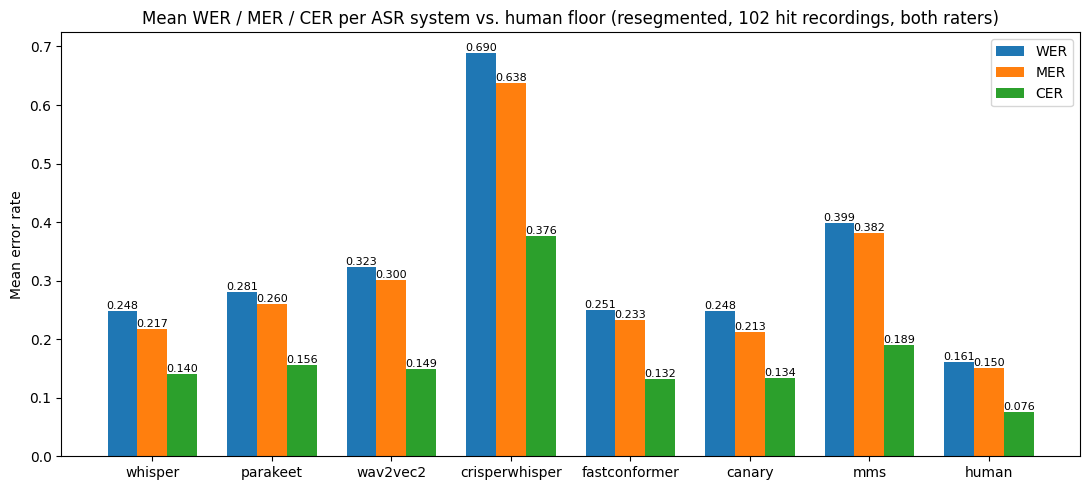

In [7]:
plot_metrics(
    scores_with_human,
    "Mean WER / MER / CER per ASR system vs. human floor (resegmented, 102 hit recordings, both raters)",
    "../plots/mms_transcription_quality_metrics.png",
    order=DISPLAY_SOURCES,
)

## MMS vs. wav2vec2 (both CTC, dedicated-Spanish vs. massively-multilingual)

Isolating the head-to-head comparison that motivated trying MMS: does training on ~1,100 languages' worth of per-language adapters help or hurt relative to a fine-tune dedicated to just Spanish, when both share the same CTC decoding shape and neither has an autoregressive language-model prior?

In [8]:
summarize(scores, order=["wav2vec2", "mms"])

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
wav2vec2,0.3230,0.3003,0.1489,0.2500,0.2500,0.0769,0.207
mms,0.3987,0.3815,0.1893,0.2857,0.2857,0.1000,0.205


## MMS vs. whisper (current baseline)

For reference, MMS against the pipeline's current production model.

In [9]:
summarize(scores, order=["whisper", "mms"])

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
whisper,0.2480,0.2166,0.1398,0.1429,0.1429,0.0476,0.349
mms,0.3987,0.3815,0.1893,0.2857,0.2857,0.1000,0.205


## Takeaways

- MMS (mean WER 0.399) scores clearly worse than wav2vec2 (0.323) on every metric -- WER, MER, and
  CER all higher, and the word-perfect rate is essentially the same (20.5% vs. 20.7%). For this
  L2-accented Spanish EIT data, the dedicated Spanish XLSR-53 fine-tune beats the broader
  ~1,100-language MMS checkpoint: breadth of language coverage did not translate into better
  per-language quality here, consistent with adapter-based multilingual training diluting
  per-language capacity relative to a single-language fine-tune.
- MMS is the second-worst system overall on this resegmented hit-recording set (WER 0.399), beating
  only crisperwhisper (0.690) and trailing every other candidate, including the other CTC model
  (wav2vec2) and both attention-decoder models (whisper, canary).
- Qualitatively, MMS's errors do match the CTC failure mode predicted in
  `docs/asr_model_alternatives.md`: literal phonetic garbling rather than fluent-sounding wrong
  text. E.g. for the stimulus "El se ducha cada mañana", MMS produced "ela seduta cara manhana" --
  garbled but still phonetically tethered to the source -- whereas SeamlessM4T (an attention-based
  model, see `analyze_seamlessm4t_transcription_quality.ipynb`) produced the fluent but entirely
  unrelated "el jefe de la policía" for the same clip.
- Net result: no pipeline change recommended. MMS's broader language coverage isn't worth the
  accuracy cost on this dataset; wav2vec2 remains the better CTC candidate if a non-autoregressive
  architecture is ever preferred over whisper/canary/fastconformer.